In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
from sklearn.preprocessing import StandardScaler
import warnings 
warnings.filterwarnings('ignore')

In [2]:
from sklearn.cluster import KMeans,DBSCAN
df=pd.read_csv('D:\ML\machne\Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [5]:
df['Gender']=df['Gender'].replace({'Male':1,'Female':0})

In [6]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
cos=['CustomerID', 'Gender', 'Age', 'Annual Income (k$)','Spending Score (1-100)']
for n in cos:
    df[n]=sc.fit_transform(df[[n]])

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
afterpca=pca.fit_transform(df)

In [9]:
df=pd.DataFrame(afterpca,columns=['co1','co2'])


In [10]:
df

,co1,co2
0,-2.316965,-0.454190
1,-2.272391,-1.474104
2,-2.454223,-0.006922
3,-2.386461,-1.749935
4,-2.397377,-0.369341
...,...,...
195,2.727733,-1.116329
196,2.834568,0.739030
197,3.073113,-0.644900
198,3.331988,0.854022


In [11]:
inertia=[]
k_range=range(1,13)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

In [12]:
inertia

[666.5065869634229,
 387.2412587721444,
 267.6362505303597,
 175.9328648323518,
 144.05105729223393,
 112.11415011287676,
 96.5300703292259,
 88.86740768221641,
 80.62938655582127,
 69.79204292374925,
 61.82296380120037,
 56.491286489572126]

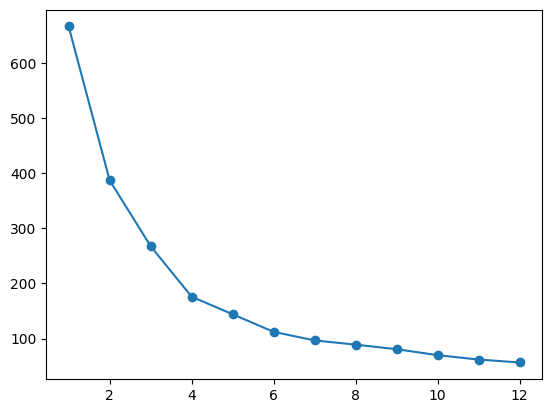

In [13]:
graph=plt.plot(k_range,inertia,marker='o')

In [14]:
kmeans=KMeans(n_clusters=6,random_state=42)

In [15]:
cluster_labels=kmeans.fit_predict(df)

In [16]:
dbsc=DBSCAN(eps=0.3,min_samples=5)
dblab=dbsc.fit_predict(df)

In [17]:
df['cluster']=cluster_labels
df['lable']=dblab

In [18]:
df

,co1,co2,cluster,lable
0,-2.316965,-0.454190,2,-1
1,-2.272391,-1.474104,2,0
2,-2.454223,-0.006922,4,-1
3,-2.386461,-1.749935,2,0
4,-2.397377,-0.369341,2,-1
...,...,...,...,...
195,2.727733,-1.116329,1,-1
196,2.834568,0.739030,3,-1
197,3.073113,-0.644900,1,-1
198,3.331988,0.854022,3,-1


<Axes: xlabel='co1', ylabel='co2'>

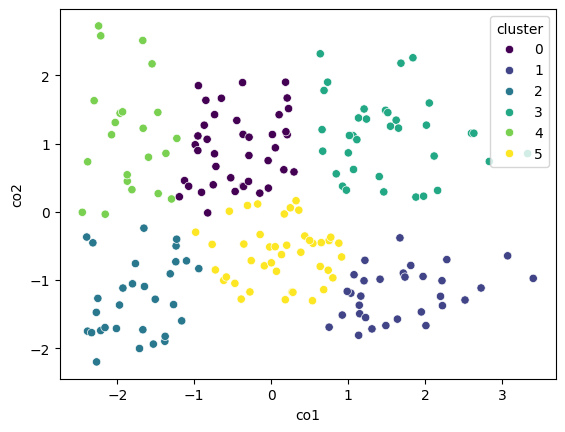

In [19]:
sns.scatterplot(x=df['co1'],
                y=df['co2'],
                hue=df['cluster'],
                palette='viridis')

<Axes: xlabel='co1', ylabel='co2'>

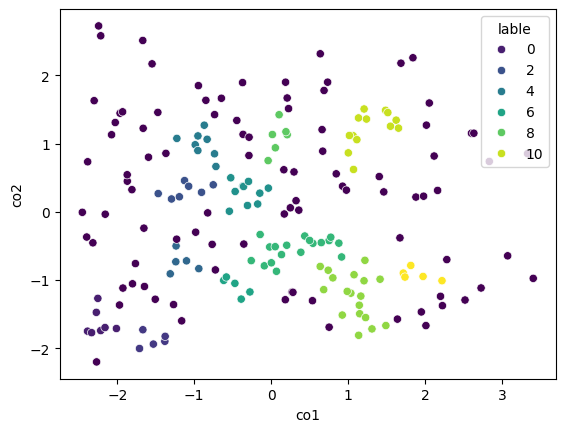

In [20]:
sns.scatterplot(x=df['co1'],
                y=df['co2'],
                hue=df['lable'],
                palette='viridis')